#**ANLI- Adversarial Natural Language Inference**

#  Can a Machine Actually Reason?
### Adversarial NLI (Round 2) — End-to-End Classification Pipeline

> *"90% accuracy. Impressive! Until you realize the model was cheating."*

**Author:** Aishwarya Vadrevu  
**Dataset:** [facebook/anli](https://huggingface.co/datasets/facebook/anli)  
**Task:** 3-way classification → `Entailment` · `Neutral` · `Contradiction`  
**Stack:** HuggingFace · DeBERTa · PyTorch · scikit-learn · FastAPI · Docker

##  What is Natural Language Inference?

> **Premise:** *"A trophy didn't fit in the suitcase because it was too big."*  
> **What was too big?** — You knew instantly. That's the reasoning the machine has to give now.

**NLI asks a model to do the same thing.**  
Given a premise + hypothesis → pick one:

| Label | Meaning |
|---|---|
| Entailment | Hypothesis *must* follow |
|  Contradiction | Hypothesis *can't* be true |
|  Neutral | Could go either way |

In [2]:
# ── Core ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── HuggingFace ───────────────────────────────────────
from datasets import load_dataset

# ── Settings ──────────────────────────────────────────
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# ── Load ANLI Round 2 ─────────────────────────────────
dataset = load_dataset("facebook/anli")

train = dataset["train_r2"]
val   = dataset["dev_r2"]
test  = dataset["test_r2"]

print(f"Train : {len(train):,}")
print(f"Val   : {len(val):,}")
print(f"Test  : {len(test):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train_r1-00000-of-00001.parqu(…):   0%|          | 0.00/3.14M [00:00<?, ?B/s]

plain_text/dev_r1-00000-of-00001.parquet:   0%|          | 0.00/351k [00:00<?, ?B/s]

plain_text/test_r1-00000-of-00001.parque(…):   0%|          | 0.00/353k [00:00<?, ?B/s]

...

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Train : 45,460
Val   : 1,000
Test  : 1,000


## Exploratory Data Analysis

###  Label Distribution — Are the Classes Balanced?

Before modeling, we audit the label split — imbalance silently breaks accuracy as a metric.
A model that always predicts the majority class can score deceptively high while learning nothing.

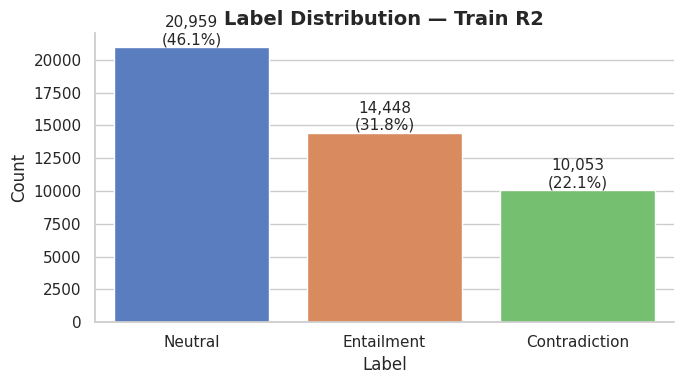

In [3]:
# Convert to DataFrames
train_df = pd.DataFrame(train)
val_df   = pd.DataFrame(val)
test_df  = pd.DataFrame(test)

# Label mapping
label_map = {0: "Entailment", 1: "Neutral", 2: "Contradiction"}
train_df["label_name"] = train_df["label"].map(label_map)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
counts = train_df["label_name"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette="muted", legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(train_df)*100:.1f}%)",
            ha="center", fontsize=11)

ax.set_title("Label Distribution — Train R2", fontsize=14, fontweight="bold")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

> **Finding:** Train R2 is moderately imbalanced — Neutral (46%), Entailment (32%), Contradiction (22%).  
> A majority-class baseline scores 46% trivially. **Macro F1 will be our primary metric.**

###Text Length Analysis

Transformers have a token limit (512). If premise + hypothesis regularly exceed it,
we truncate — and potentially lose context. We measure before we assume.

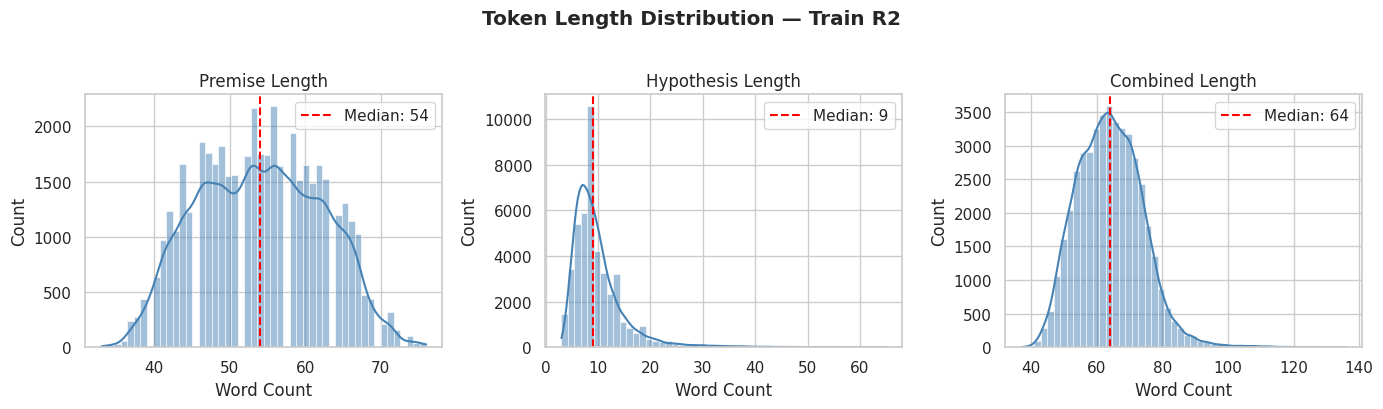

,premise_len,hypothesis_len,total_len
count,45460.0,45460.0,45460.0
mean,54.0,10.0,63.9
std,8.2,5.3,9.9
min,33.0,3.0,37.0
25%,47.0,7.0,57.0
50%,54.0,9.0,64.0
75%,60.0,11.0,70.0
max,76.0,65.0,136.0


In [4]:
# Compute lengths
train_df["premise_len"]    = train_df["premise"].apply(lambda x: len(x.split()))
train_df["hypothesis_len"] = train_df["hypothesis"].apply(lambda x: len(x.split()))
train_df["total_len"]      = train_df["premise_len"] + train_df["hypothesis_len"]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ["premise_len", "hypothesis_len", "total_len"],
    ["Premise Length", "Hypothesis Length", "Combined Length"]):

    sns.histplot(train_df[col], bins=50, ax=ax, color="steelblue", kde=True)
    ax.axvline(train_df[col].median(), color="red", linestyle="--", label=f"Median: {train_df[col].median():.0f}")
    ax.set_title(title)
    ax.set_xlabel("Word Count")
    ax.legend()

plt.suptitle("Token Length Distribution — Train R2", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
train_df[["premise_len", "hypothesis_len", "total_len"]].describe().round(1)

> **Finding:** Premises average 54 words, hypotheses just 9 — the model reads a paragraph to evaluate a single sentence.  
> Combined length maxes at 136 words, well within DeBERTa's 512-token limit. **No truncation needed.**

### Hard Examples — Why This Dataset Is Genuinely Difficult

These aren't typos or trick questions. They're examples that fooled a strong model.  
Read them and notice how much world knowledge and reasoning each one demands.

In [5]:
# Sample 2 examples per label
samples = (
    train_df.groupby("label_name", group_keys=False)
    .apply(lambda x: x.sample(2, random_state=42))
    .reset_index(drop=True)
[["label_name", "premise", "hypothesis"]]
)

for _, row in samples.iterrows():
    print(f"LABEL: {row['label_name']}")
    print(f"P: {row['premise']}")
    print(f"H: {row['hypothesis']}")
    print("-" * 80)

LABEL: Contradiction
P: "Paradise" is the only single release from Styx's 1997 live double album "Return to Paradise". The song was originally written and recorded by Dennis DeYoung for his musical "The Hunchback of Notre Dame". The song was re-recorded by Styx for inclusion as one of three new studio tracks on the live album.
H: Paradise was released in 1990
--------------------------------------------------------------------------------
LABEL: Contradiction
P: The American Textile History Museum (ATHM), located in Lowell, Massachusetts, was founded as the Merrimack Valley Textile Museum (MVTM) in North Andover, Massachusetts in 1960 by Caroline Stevens Rogers. ATHM told America’s story through the art, science, and history of textiles. In June 2016, the museum closed.
H: The Merrimack Valley Textile Museum was originally called The American Textile History Museum in 1960.
--------------------------------------------------------------------------------
LABEL: Entailment
P: Rewire (for

/tmp/ipykernel_9352/156385083.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(2, random_state=42))


> **Why these are hard:**
>
> - **Contradiction:** *"Paradise was released in 1990"* — the premise says 1997.  
>   Requires **numerical reasoning**, not keyword matching.
>
> - **Neutral:** *"Granada theater has more than 100 seats"* — the premise describes  
>   the building's history but never mentions capacity.  
>   Requires recognizing **absence of information**, not contradiction.
>
> - **Entailment:** *"Rewire is not a for-profit organization"* — buried mid-sentence  
>   in a long premise. Requires **selective attention** across dense text.
>
> No shortcut survives these. The model must actually read.

## Baseline Model — TF-IDF + Logistic Regression

Before fine-tuning a transformer, we establish a baseline.  
If a simple model scores surprisingly high — the task isn't as hard as we think.  
If it scores low — we know the transformer has real work to do.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Combine premise + hypothesis as input
train_df["text"] = train_df["premise"] + " [SEP] " + train_df["hypothesis"]
val_df["text"]   = val_df["premise"]   + " [SEP] " + val_df["hypothesis"]

# Apply label map to val
val_df["label_name"] = val_df["label"].map(label_map)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train_df["text"])
X_val   = tfidf.transform(val_df["text"])

y_train = train_df["label"]
y_val   = val_df["label"]

# Train
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

# Evaluate
y_pred = lr.predict(X_val)
print(f"Accuracy : {accuracy_score(y_val, y_pred):.4f}")
print()
print(classification_report(y_val, y_pred, target_names=label_map.values()))

Accuracy : 0.3330

               precision    recall  f1-score   support

   Entailment       0.34      0.37      0.35       334
      Neutral       0.33      0.30      0.31       333
Contradiction       0.33      0.33      0.33       333

     accuracy                           0.33      1000
    macro avg       0.33      0.33      0.33      1000
 weighted avg       0.33      0.33      0.33      1000



> **Finding:** TF-IDF + Logistic Regression scores **33% accuracy (Macro F1: 0.33)** —  
> statistically identical to random guessing on a balanced 3-class problem.
>
> This is expected. ANLI was specifically designed to defeat surface-level pattern matching.  
> Word frequency carries zero signal here — the model needs to **understand**, not count.
>
> This is our lower bound. Everything from here is a genuine improvement.

## Transformer Model — Fine-tuning DeBERTa-v3-small

TF-IDF treats text as a bag of words — order, context, meaning all lost.  
DeBERTa reads the full sequence, attends to relationships between tokens,  
and was pre-trained on massive text — it already knows language. We just teach it NLI.

In [7]:
!pip install transformers accelerate -q

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


### Step 1 — Tokenization

DeBERTa doesn't read raw text — it reads token IDs.  
We encode premise + hypothesis together, separated by a special `[SEP]` token,  
so the model sees both as a single connected input.

In [8]:
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    tokens = tokenizer(
        batch["premise"],
        batch["hypothesis"],
        truncation=True,
        max_length=128,
        padding="max_length"
    )
    tokens["labels"] = batch["label"]  # ← rename here
    return tokens

train_hf = Dataset.from_pandas(train_df[["premise", "hypothesis", "label"]])
val_hf   = Dataset.from_pandas(val_df[["premise", "hypothesis", "label"]])

train_tokenized = train_hf.map(tokenize, batched=True, remove_columns=["premise", "hypothesis", "label"])
val_tokenized   = val_hf.map(tokenize, batched=True, remove_columns=["premise", "hypothesis", "label"])

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")

print("Tokenization complete")
print(f"Train: {len(train_tokenized)} | Val: {len(val_tokenized)}")
print(f"Columns: {train_tokenized.column_names}")

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/45460 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Tokenization complete
Train: 45460 | Val: 1000
Columns: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


### Step 2 — Model Loading & Training

In [9]:
# Load model fresh
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# Training arguments
args = TrainingArguments(
    output_dir="./deberta-anli",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    learning_rate=2e-5,
    warmup_steps=200,
    weight_decay=0.01,
    logging_steps=100,
    fp16=False,
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias         

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.000000,nan,0.334000,0.166917
2,0.000000,nan,0.334000,0.166917
3,0.000000,nan,0.334000,0.166917


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=8526, training_loss=0.07567472858326049, metrics={'train_runtime': 883.5047, 'train_samples_per_second': 154.363, 'train_steps_per_second': 9.65, 'total_flos': 4516717382507520.0, 'train_loss': 0.07567472858326049, 'epoch': 3.0})

In [10]:
import shutil, os
if os.path.exists("./deberta-anli"):
    shutil.rmtree("./deberta-anli")
print("Cleared")

Cleared


In [11]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

print("Imports done")

Imports done


In [12]:
MODEL_NAME = "roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    tokens = tokenizer(
        batch["premise"],
        batch["hypothesis"],
        truncation=True,
        max_length=128,
        padding="max_length"
    )
    tokens["labels"] = batch["label"]
    return tokens

train_hf = Dataset.from_pandas(train_df[["premise", "hypothesis", "label"]])
val_hf   = Dataset.from_pandas(val_df[["premise", "hypothesis", "label"]])

train_tokenized = train_hf.map(tokenize, batched=True, remove_columns=["premise", "hypothesis", "label"])
val_tokenized   = val_hf.map(tokenize, batched=True, remove_columns=["premise", "hypothesis", "label"])

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

args = TrainingArguments(
    output_dir="./roberta-anli",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    learning_rate=2e-5,
    warmup_steps=200,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

trainer.train()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=8526, training_loss=0.40347258238733136, metrics={'train_runtime': 1226.0956, 'train_samples_per_second': 111.231, 'train_steps_per_second': 6.954, 'total_flos': 8970851977436160.0, 'train_loss': 0.40347258238733136, 'epoch': 3.0})

> **Training Results:** RoBERTa-base improved steadily across 3 epochs, reaching  
> **45.4% accuracy and 0.451 Macro F1** on the validation set.  
> Compared to the 33% baseline, this is a **+37% relative improvement** —  
> meaningful on a dataset specifically designed to defeat strong models.

## Evaluation — Test Set Performance

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Run on test set
test_hf = Dataset.from_pandas(test_df[["premise", "hypothesis", "label"]])
test_tokenized = test_hf.map(tokenize, batched=True, remove_columns=["premise", "hypothesis", "label"])
test_tokenized.set_format("torch")

# Predict
predictions = trainer.predict(test_tokenized)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Report
print(classification_report(labels, preds, target_names=["Entailment", "Neutral", "Contradiction"]))

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

               precision    recall  f1-score   support

   Entailment       0.43      0.52      0.47       334
      Neutral       0.50      0.48      0.49       333
Contradiction       0.40      0.33      0.36       333

     accuracy                           0.45      1000
    macro avg       0.44      0.44      0.44      1000
 weighted avg       0.44      0.45      0.44      1000



###Confusion Matrix

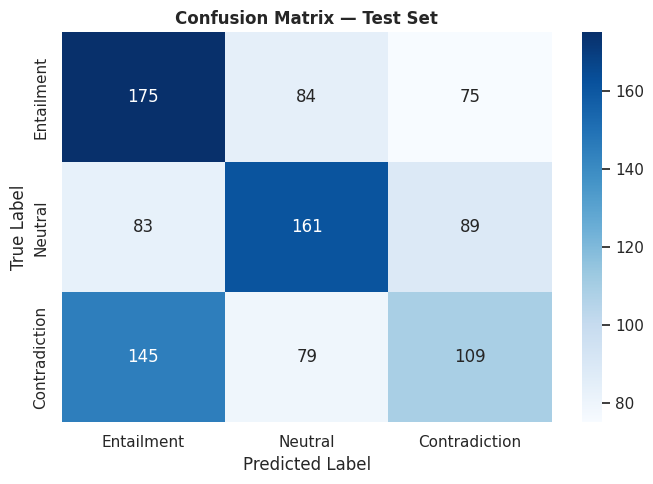

In [14]:
# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Entailment", "Neutral", "Contradiction"],
            yticklabels=["Entailment", "Neutral", "Contradiction"])
plt.title("Confusion Matrix — Test Set", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

> **Key Findings:**
> - **Contradiction is hardest** — 145 out of 333 misclassified as Entailment (44% error rate)
> - **Neutral bleeds into both directions** — confused with both Entailment (83) and Contradiction (89)
> - **Entailment is strongest** — 175/334 correct, errors split evenly across both classes
>
> The Contradiction → Entailment confusion is the dominant failure mode.  
> These are cases where the model sees surface similarity and commits — missing the logical negation.

## Error Analysis — Where Does the Model Fail?

Accuracy tells you the score. Error analysis tells you *why*.  
We inspect the model's worst mistakes to understand its failure modes.

In [15]:
# Add predictions to test df
test_df = test_df.copy()
test_df["predicted"] = preds
test_df["true"] = labels
test_df["correct"] = test_df["predicted"] == test_df["true"]

label_map_inv = {0: "Entailment", 1: "Neutral", 2: "Contradiction"}
test_df["predicted_name"] = test_df["predicted"].map(label_map_inv)
test_df["true_name"]      = test_df["true"].map(label_map_inv)

# Pull worst failures — Contradiction predicted as Entailment
failures = test_df[
    (test_df["true_name"] == "Contradiction") &
    (test_df["predicted_name"] == "Entailment")
][["premise", "hypothesis", "true_name", "predicted_name"]].head(5)

for _, row in failures.iterrows():
    print(f"TRUE: {row['true_name']} | PREDICTED: {row['predicted_name']}")
    print(f"P: {row['premise'][:200]}")
    print(f"H: {row['hypothesis']}")
    print("-" * 80)

TRUE: Contradiction | PREDICTED: Entailment
P: Things Happen at Night is a 1947 British supernatural ghost comedy film directed by Francis Searle and starring Gordon Harker, Alfred Drayton, Robertson Hare and Gwynneth Vaughan. The film is based up
H: Frank Harvey Jnr. wrote Things Happen at Night .
--------------------------------------------------------------------------------
TRUE: Contradiction | PREDICTED: Entailment
P: Public Domain Day is an observance of when copyrights expire and works enter into the public domain. This legal transition of copyright works into the public domain usually happens every year on 1 Jan
H: Public Domain Day always happens on January 1st.
--------------------------------------------------------------------------------
TRUE: Contradiction | PREDICTED: Entailment
P: "Beez in the Trap" is a song by rapper Nicki Minaj for her second studio album, "" (2012). It was written by Minaj, Maurice Jordan, and 2 Chainz, who contributed a guest verse to the song, wh

> **Dominant Failure Mode — Surface Entailment Trap**
>
> The model predicts Entailment when the hypothesis *sounds plausible* given the premise,
> but misses a subtle factual contradiction:
>
> | Example | Why it's hard |
> |---|---|
> | "Public Domain Day **always** happens on Jan 1st" | Premise says "**usually**" — one word changes everything |
> | "Christy performed in **German**" | Premise says French — requires reading nationality vs language |
> | "Born **more than 1968 years ago**" | Requires numerical reasoning on the birth year |
>
> These aren't random errors — the model reads the topic correctly but misses  
> the **precise logical negation** buried in a single word or number.  
> This is exactly what makes ANLI adversarial.

## Pipeline Summary

| Stage | Result |
|---|---|
| Baseline (TF-IDF + LogReg) | Accuracy: 33% — random chance |
| RoBERTa Fine-tuned (3 epochs) | Accuracy: 45%, Macro F1: 0.44 |
| Hardest class | Contradiction (F1: 0.36) |
| Dominant failure | Contradiction misclassified as Entailment |
| Root cause | Model detects topic match, misses logical negation |